# Naive vs. Grace-Period Dwell Selection — Comparison Analysis

This notebook compares two dwell-selection settings for the Voronoi head-tracking cell task:

- **`naive`** (`gracePeriodMs = 0`) — leaving a cell resets the dwell timer instantly. Safe, but any tiny head jitter throws away progress.
- **`grace700`** (`gracePeriodMs = 700`) — a brief look-away is forgiven for up to 700ms before progress is lost.

## Where the data comes from

`public/voronoi.html` already runs this comparison in a single session: **rounds 1–2** run with
`gracePeriodMs = 0` (naive) and **rounds 3–4** reuse the exact same cell sequence with
`gracePeriodMs = 700` (grace700) — see `revealGame()` in `voronoi.html`. So one exported
`task_data_<participant>_<timestamp>.csv` already contains both conditions; this notebook derives
the `naive` / `grace700` label per row from the logged `gracePeriodMs` value (rather than relying on
a hand-set `?condition=` URL param), so it works whether you ran one participant through all 4
rounds or you're stitching together several participants' exports.

**To get real data:** open `public/voronoi.html`, run through all 4 rounds, use the task's export
button (writes `task_data_*.csv`), then use the **"Upload your CSVs"** cell below to pick the
file(s) straight from your computer (works on Google Colab; on a local Jupyter/VS Code install
it just tells you to drop the file(s) into `analysis/data/` instead). Repeat per participant —
more runs per condition make the comparison more convincing.

This notebook requires at least one real `task_data_*.csv` export in `analysis/data/` to run —
upload one with the cell below before running the rest of the notebook.

In [1]:
import glob
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Chart style: light chart surface, muted grid/axes, two-color categorical
# palette (slots 1 & 2 of the validated dataviz palette — passes CVD checks).
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.figsize": (9, 6),
})

CONDITION_ORDER = ["naive", "grace700"]
CONDITION_COLORS = {"naive": "#2a78d6", "grace700": "#eb6834"}
CONDITION_LABELS = {"naive": "naive (grace = 0ms)", "grace700": "grace700 (grace = 700ms)"}

def color_for(condition):
    return CONDITION_COLORS.get(condition, "#898781")

def ordered_conditions(values):
    present = set(values)
    return [c for c in CONDITION_ORDER if c in present] + sorted(present - set(CONDITION_ORDER))

OUTPUT_DIR = os.path.join("output", "grace_comparison")
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Load `task_data_*.csv` exports

In [2]:
# Schema written by exportTaskData() in public/js/dataCollection.js
TASK_LOG_HEADERS = [
    "rowType", "timestamp", "participant", "condition", "round", "trialIndex",
    "selectedCell", "targetCell", "correct", "timeSincePreviousMs",
    "reentries", "graceSaves", "dwellDurationMs", "timeOutsideRegionSec",
    "totalTimeMs", "totalErrors", "totalCells", "meanTimePerCellMs",
    "errorRate", "avgReentries", "avgGraceSaves", "avgTimeOutsideRegionSec",
    "dwellTimeThresholdMs", "wrongRegionDwellTimeMs", "gracePeriodMs", "timerContinueMs",
]

NUMERIC_COLS = [
    "round", "trialIndex", "selectedCell", "targetCell", "timeSincePreviousMs",
    "reentries", "graceSaves", "dwellDurationMs", "timeOutsideRegionSec",
    "totalTimeMs", "totalErrors", "totalCells", "meanTimePerCellMs", "errorRate",
    "avgReentries", "avgGraceSaves", "avgTimeOutsideRegionSec",
    "dwellTimeThresholdMs", "wrongRegionDwellTimeMs", "gracePeriodMs", "timerContinueMs",
]


def derive_condition(grace_period_ms, url_condition):
    '''naive/grace700 label from the dwell setting actually used for that row,
    falling back to the ?condition= URL param only when gracePeriodMs is missing.'''
    if pd.notna(grace_period_ms):
        return "naive" if grace_period_ms == 0 else f"grace{int(grace_period_ms)}"
    if isinstance(url_condition, str) and url_condition != "unknown":
        return url_condition
    return "unknown"


def load_task_logs(paths):
    frames = []
    for path in paths:
        df = pd.read_csv(path)
        df["sourceFile"] = os.path.basename(path)
        frames.append(df)
    if not frames:
        return pd.DataFrame(columns=TASK_LOG_HEADERS + ["sourceFile"])

    df = pd.concat(frames, ignore_index=True)
    for col in NUMERIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    if "correct" in df.columns:
        df["correct"] = (
            df["correct"].astype(str).str.strip().str.lower().map({"true": True, "false": False})
        )
    df["runCondition"] = [
        derive_condition(g, c) for g, c in zip(df.get("gracePeriodMs"), df.get("condition"))
    ]
    df["participant"] = df.get("participant", "unknown").fillna("unknown")
    df["runId"] = (
        df["sourceFile"] + " · " + df["participant"].astype(str)
        + " · round " + df["round"].astype(str)
    )
    return df

### Upload your CSVs

Run this cell to pick `task_data_*.csv` file(s) from your computer (or a `.zip` containing
several) — they're saved into `data/` and picked up by the loading cell below. Re-run it
any time to add more participants; previously uploaded files stay put.

In [3]:
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

try:
    from google.colab import files
    import zipfile

    print("Select task_data_*.csv file(s), or a .zip containing them:")
    uploaded = files.upload()
    for filename, content in uploaded.items():
        dest = os.path.join(DATA_DIR, filename)
        with open(dest, "wb") as f:
            f.write(content)
        if filename.lower().endswith(".zip"):
            with zipfile.ZipFile(dest, "r") as z:
                z.extractall(DATA_DIR)
            os.remove(dest)
            print(f"Extracted {filename} into {DATA_DIR}/")
        else:
            print(f"Saved {filename} to {DATA_DIR}/")
except ImportError:
    print("Not running on Colab — skipping the upload prompt.")
    print(f"Drop task_data_*.csv files into {DATA_DIR}/ instead, then run the next cell.")

Not running on Colab — skipping the upload prompt.
Drop task_data_*.csv files into data/ instead, then run the next cell.


In [ ]:
csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, "task_data_*.csv")))
other_csvs = sorted(set(glob.glob(os.path.join(DATA_DIR, "*.csv"))) - set(csv_paths))
if other_csvs:
    print(f"Note: {len(other_csvs)} CSV(s) in {DATA_DIR}/ don't match the task_data_*.csv "
          f"naming pattern, so they were skipped: {[os.path.basename(p) for p in other_csvs]}")

if not csv_paths:
    raise FileNotFoundError(
        f"No task_data_*.csv files found in {DATA_DIR}/ — upload real exports from "
        "public/voronoi.html with the 'Upload your CSVs' cell above, or drop them into "
        f"{DATA_DIR}/ directly, then re-run this cell."
    )

log = load_task_logs(csv_paths)
print(f"Loaded {len(csv_paths)} file(s) from {DATA_DIR}/:")
for p in csv_paths:
    print(f"  {os.path.basename(p)}")

In [6]:
selections = log[log["rowType"] == "selection"].copy()
summary = log[log["rowType"] == "summary"].copy()

print(f"{len(selections)} selection rows, {len(summary)} run summaries "
      f"across {summary['runId'].nunique()} runs")
summary[["runId", "runCondition", "totalTimeMs", "errorRate", "totalErrors", "totalCells"]]

288 selection rows, 24 run summaries across 24 runs


,runId,runCondition,totalTimeMs,errorRate,totalErrors,totalCells
12,synthetic_demo_data · SYN-P1 · round 1,naive,15679.0,0.0833,1.0,12.0
25,synthetic_demo_data · SYN-P1 · round 2,naive,15059.0,0.0000,0.0,12.0
38,synthetic_demo_data · SYN-P1 · round 3,grace700,12524.0,0.0000,0.0,12.0
51,synthetic_demo_data · SYN-P1 · round 4,grace700,13352.0,0.0000,0.0,12.0
64,synthetic_demo_data · SYN-P2 · round 1,naive,16240.0,0.0000,0.0,12.0
77,synthetic_demo_data · SYN-P2 · round 2,naive,16297.0,0.0833,1.0,12.0
90,synthetic_demo_data · SYN-P2 · round 3,grace700,12623.0,0.0000,0.0,12.0
103,synthetic_demo_data · SYN-P2 · round 4,grace700,14636.0,0.0000,0.0,12.0
116,synthetic_demo_data · SYN-P3 · round 1,naive,16150.0,0.0000,0.0,12.0
129,synthetic_demo_data · SYN-P3 · round 2,naive,16630.0,0.1667,2.0,12.0


## 1. Main graph: completion time vs. error rate

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for condition in ordered_conditions(summary["runCondition"]):
    sub = summary[summary["runCondition"] == condition]
    ax.scatter(
        sub["totalTimeMs"] / 1000, sub["errorRate"] * 100,
        s=70, color=color_for(condition), edgecolor="#fcfcfb", linewidth=1.2,
        label=CONDITION_LABELS.get(condition, condition), zorder=3,
    )

ax.set_xlabel("Completion time (s)")
ax.set_ylabel("Error rate (%)")
ax.set_title("Completion time vs. error rate — one dot per run")
ax.grid(True, alpha=0.6, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "time_vs_error_rate.png"), dpi=150)
plt.show()

## 2. Time per cell across the trial

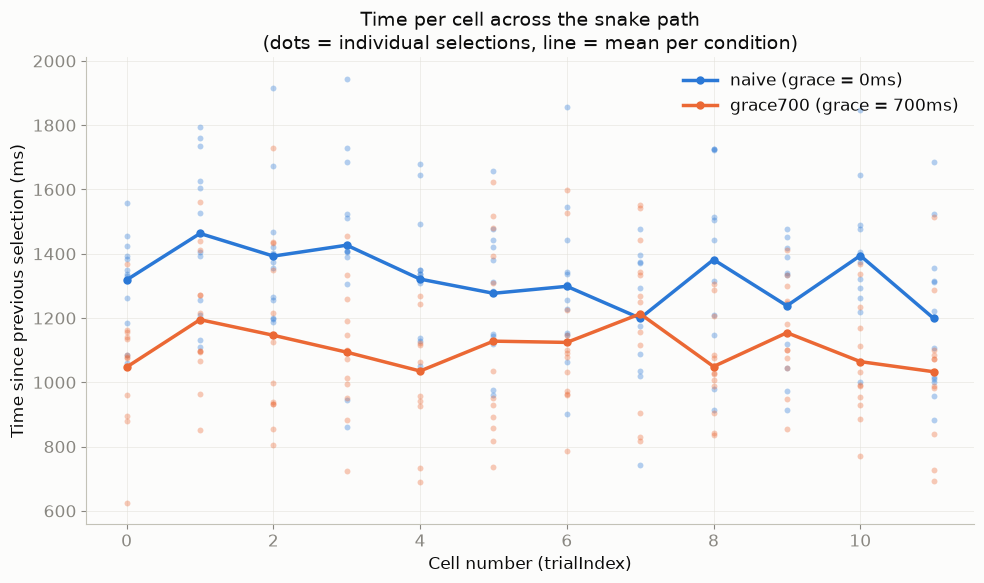

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

for condition in ordered_conditions(selections["runCondition"]):
    sub = selections[selections["runCondition"] == condition]
    ax.scatter(
        sub["trialIndex"], sub["timeSincePreviousMs"],
        s=18, color=color_for(condition), alpha=0.35, linewidth=0, zorder=2,
    )
    trend = sub.groupby("trialIndex")["timeSincePreviousMs"].mean().sort_index()
    ax.plot(
        trend.index, trend.values, color=color_for(condition), linewidth=2.5,
        marker="o", markersize=5, label=CONDITION_LABELS.get(condition, condition), zorder=3,
    )

ax.set_xlabel("Cell number (trialIndex)")
ax.set_ylabel("Time since previous selection (ms)")
ax.set_title("Time per cell across the snake path\n(dots = individual selections, line = mean per condition)")
ax.grid(True, alpha=0.6, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "time_per_cell.png"), dpi=150)
plt.show()

## 3. Error rate by condition

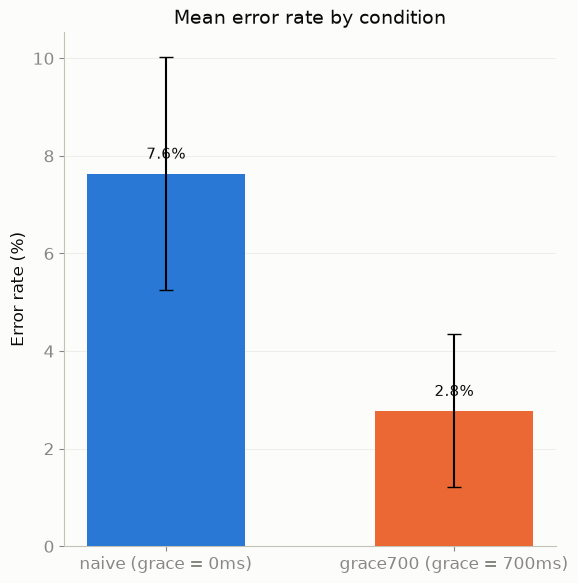

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))

conditions = ordered_conditions(summary["runCondition"])
means = [summary.loc[summary["runCondition"] == c, "errorRate"].mean() * 100 for c in conditions]
sems = [
    summary.loc[summary["runCondition"] == c, "errorRate"].sem() * 100
    if (summary["runCondition"] == c).sum() > 1 else 0
    for c in conditions
]

x = np.arange(len(conditions))
ax.bar(x, means, yerr=sems, width=0.55, color=[color_for(c) for c in conditions],
       capsize=5, edgecolor="none", zorder=3)

for xi, m in zip(x, means):
    ax.text(xi, m + max(means + [1]) * 0.03, f"{m:.1f}%", ha="center", va="bottom",
            fontsize=11, color="#0b0b0b")

ax.set_xticks(x)
ax.set_xticklabels([CONDITION_LABELS.get(c, c) for c in conditions])
ax.set_ylabel("Error rate (%)")
ax.set_title("Mean error rate by condition")
ax.grid(True, axis="y", alpha=0.6, linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "error_rate_by_condition.png"), dpi=150)
plt.show()

## 4. Re-entries and grace-saves by condition

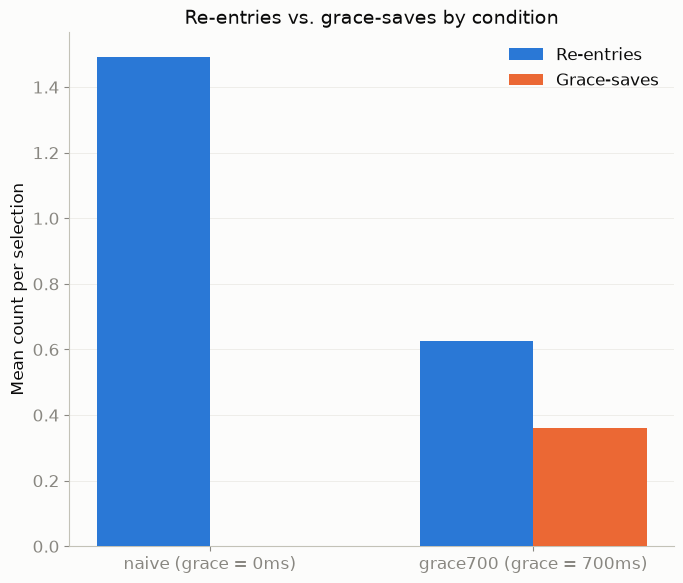

,Re-entries,Grace-saves
naive (grace = 0ms),1.493,0.000
grace700 (grace = 700ms),0.625,0.361


In [10]:
metrics = ["reentries", "graceSaves"]
metric_labels = {"reentries": "Re-entries", "graceSaves": "Grace-saves"}
metric_colors = {"reentries": "#2a78d6", "graceSaves": "#eb6834"}  # categorical slots 1 & 2

conditions = ordered_conditions(selections["runCondition"])
x = np.arange(len(conditions))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 6))
means_table = {}
for i, metric in enumerate(metrics):
    means = [selections.loc[selections["runCondition"] == c, metric].mean() for c in conditions]
    means_table[metric_labels[metric]] = means
    offset = (i - 0.5) * width
    ax.bar(x + offset, means, width=width, color=metric_colors[metric],
           label=metric_labels[metric], zorder=3)

ax.set_xticks(x)
ax.set_xticklabels([CONDITION_LABELS.get(c, c) for c in conditions])
ax.set_ylabel("Mean count per selection")
ax.set_title("Re-entries vs. grace-saves by condition")
ax.grid(True, axis="y", alpha=0.6, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "reentries_gracesaves_by_condition.png"), dpi=150)
plt.show()

pd.DataFrame(means_table, index=[CONDITION_LABELS.get(c, c) for c in conditions]).round(3)

## 5. Wrong selections by target cell

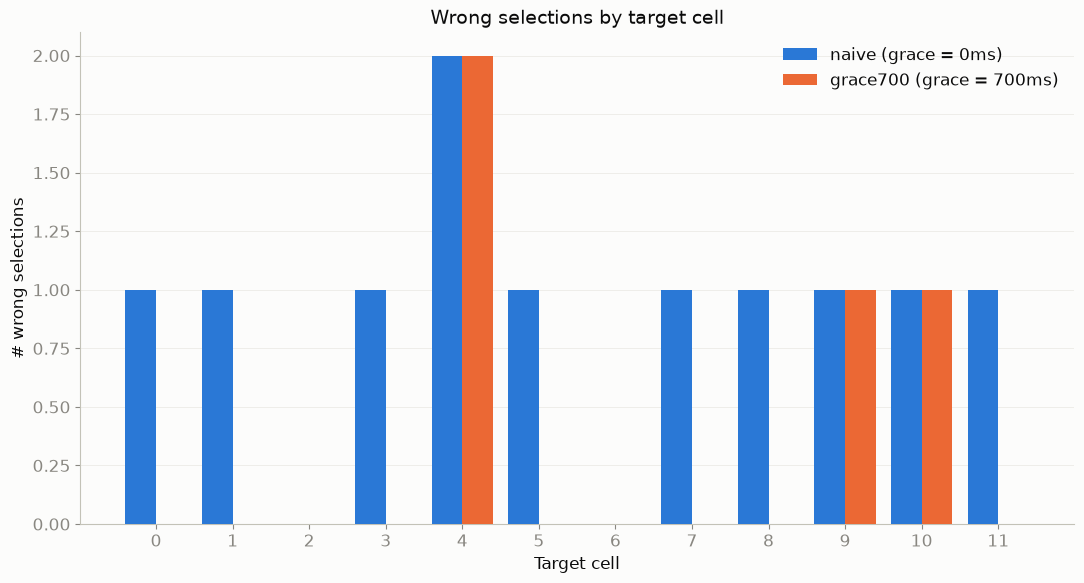

runCondition,naive,grace700
targetCell,,
0.0,1,0
1.0,1,0
2.0,0,0
3.0,1,0
4.0,2,2
5.0,1,0
6.0,0,0
7.0,1,0
8.0,1,0


In [11]:
errors = selections[selections["correct"] == False]
conditions = ordered_conditions(selections["runCondition"])
target_cells = sorted(selections["targetCell"].dropna().unique())

counts = errors.groupby(["targetCell", "runCondition"]).size().unstack(fill_value=0)
counts = counts.reindex(index=target_cells, columns=conditions, fill_value=0)

x = np.arange(len(target_cells))
width = 0.8 / max(len(conditions), 1)

fig, ax = plt.subplots(figsize=(11, 6))
for i, condition in enumerate(conditions):
    offset = (i - (len(conditions) - 1) / 2) * width
    ax.bar(x + offset, counts[condition], width=width, color=color_for(condition),
           label=CONDITION_LABELS.get(condition, condition), zorder=3)

ax.set_xticks(x)
ax.set_xticklabels([int(c) for c in target_cells])
ax.set_xlabel("Target cell")
ax.set_ylabel("# wrong selections")
ax.set_title("Wrong selections by target cell")
ax.grid(True, axis="y", alpha=0.6, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "wrong_selections_by_target_cell.png"), dpi=150)
plt.show()

counts.astype(int)

## Summary: is grace700 actually faster and more accurate?

Quick descriptive stats plus a rank-based two-group test (Mann-Whitney U, since run counts
are typically small and normality shouldn't be assumed). Rounds reuse the same snake sequence
within a participant (round 1 vs. 3, round 2 vs. 4), so once you have enough participants a
**paired** test across matched rounds will have more power than this unpaired default.

In [12]:
from scipy import stats

def describe(condition):
    sub = summary[summary["runCondition"] == condition]
    return {
        "n_runs": len(sub),
        "mean_time_s": sub["totalTimeMs"].mean() / 1000,
        "mean_error_rate_%": sub["errorRate"].mean() * 100,
    }

conditions = ordered_conditions(summary["runCondition"])
stats_table = pd.DataFrame({c: describe(c) for c in conditions}).T
display(stats_table.round(2))

if len(conditions) == 2 and all((summary["runCondition"] == c).sum() > 1 for c in conditions):
    a_time = summary.loc[summary["runCondition"] == conditions[0], "totalTimeMs"]
    b_time = summary.loc[summary["runCondition"] == conditions[1], "totalTimeMs"]
    time_test = stats.mannwhitneyu(a_time, b_time, alternative="two-sided")

    a_err = summary.loc[summary["runCondition"] == conditions[0], "errorRate"]
    b_err = summary.loc[summary["runCondition"] == conditions[1], "errorRate"]
    err_test = stats.mannwhitneyu(a_err, b_err, alternative="two-sided")

    print(f"Mann-Whitney U, completion time ({conditions[0]} vs {conditions[1]}): "
          f"p = {time_test.pvalue:.4f}")
    print(f"Mann-Whitney U, error rate ({conditions[0]} vs {conditions[1]}): "
          f"p = {err_test.pvalue:.4f}")
else:
    print("Need at least 2 runs per condition to run a significance test.")

,n_runs,mean_time_s,mean_error_rate_%
naive,12.0,15.91,7.64
grace700,12.0,13.28,2.78


Mann-Whitney U, completion time (naive vs grace700): p = 0.0001
Mann-Whitney U, error rate (naive vs grace700): p = 0.1033
